# Pipeline predictions — first look

Basic analysis of the first results from the programme-segmentation + metadata pipeline
(`../kdl-metadata-385.v2(predictions-385.csv`). **One row = one predicted programme**, keyed by the
source video file (`DODfilenameprefix`), so a file with several programmes appears on several rows.
This notebook was produced using Claude coding assistant. All content has been checked by a human reviewer. Errors or inconsistencies can be reported to issa@kcl.ac.uk

Sections: 1. load · 2. overview · 3. cleaning audit and fixes · 4. descriptive statistics · 5. charts · 6. conclusions · 7. human watching list · 8. which files to watch first · 9. spreadsheet export · 10. plain-language takeaways.

Nothing here prints or exports the full table — only samples, aggregates and charts. Colours match
`../metadata_hierarchy.html` (blue = Grampian, orange = non-Grampian).

## 1. Load

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PREDICTIONS_CSV = Path("../kdl-metadata-385.v2(predictions-385.csv")
if not PREDICTIONS_CSV.exists():
    raise FileNotFoundError(f"Predictions file not found: {PREDICTIONS_CSV.resolve()}")

COLOR = {"Grampian": "#2a78d6", "non-Grampian": "#eb6834"}   # same hues as the dashboard
INK, MUTED, GRID = "#1a1a19", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.family": "sans-serif", "font.size": 10,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
})

The file is **not UTF-8**: it is Windows-1252 (cp1252) — e.g. byte `0x96` is an en dash — so a plain
`pd.read_csv(path)` fails with a `UnicodeDecodeError`. Same encoding as the NLS metadata CSVs.
The long column headers are shortened (mapping kept below so nothing is lost).

In [2]:
COLUMNS = {
    "batch": "batch",
    "DODfilenameprefix": "dod",
    "kdl_prog (HH.MM.SS-duration-in-secs)": "prog",
    "title": "title",
    "year": "year",
    "place": "place",
    "colour": "colour",
    "types": "types",
    "fiction": "fiction",
    "summary": "summary",
    "synopsis": "synopsis",
    "segments (timecodes relatives to kdl_prog)": "segments",
    "credits": "credits",
    "UNCONTROLLED keywords": "keywords",
}

raw = pd.read_csv(PREDICTIONS_CSV, encoding="cp1252")
assert set(raw.columns) == set(COLUMNS), f"unexpected columns: {set(raw.columns) ^ set(COLUMNS)}"
df = raw.rename(columns=COLUMNS)

# `batch` is "Grampian" or blank. Blank = the non-Grampian films (checked below: 200 Grampian files).
assert set(df["batch"].dropna().unique()) == {"Grampian"}
df["collection"] = np.where(df["batch"].eq("Grampian"), "Grampian", "non-Grampian")

df.shape

(1975, 15)

## 2. Overview

In [3]:
overview = df.groupby("collection").agg(programmes=("prog", "size"), files=("dod", "nunique"))
overview.loc["total"] = [len(df), df["dod"].nunique()]
overview["programmes_per_file"] = (overview["programmes"] / overview["files"]).round(1)
overview

,programmes,files,programmes_per_file
collection,,,
Grampian,1774,200,8.9
non-Grampian,201,185,1.1
total,1975,385,5.1


The NLS samples we processed consist of 200 Grampian + 200 non-Grampian files. All 200 Grampian files are here;
the non-Grampian side has 185 of the 200 films (the other 15 were not processed in this run).

In [4]:
per_file = df.groupby(["collection", "dod"]).size().rename("n_progs").reset_index()
per_file.groupby("collection")["n_progs"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
collection,,,,,,,,
Grampian,200.0,8.9,8.7,1.0,4.0,7.0,11.0,102.0
non-Grampian,185.0,1.1,0.5,1.0,1.0,1.0,1.0,6.0


In [5]:
# Spot-check a few rows (narrow columns only — no full-table dump)
df[["collection", "dod", "prog", "title", "year", "place", "types"]].sample(6, random_state=0)

,collection,dod,prog,title,year,place,types
18,non-Grampian,102826763,00.00.00-343,Wishaw Co-operative Society Ltd Gala Day,1909.0,Wishaw; Scotland,documentary
294,Grampian,139439541,00.55.04-410,NaN,NaN,"Glasgow, Scotland",documentary
1899,non-Grampian,255686261,00.44.49-1,NaN,NaN,NaN,NaN
526,Grampian,139482696,00.54.35-317,NaN,NaN,"Orkney, Scotland",documentary
609,Grampian,139482727,00.15.57-523,NaN,NaN,"New Zealand (probable, Wellington-area buildin...",tv sports; documentary
712,Grampian,139482759,00.36.35-205,NaN,NaN,NaN,documentary


## 3. Cleaning audit

Field-by-field: how complete it is, how many distinct values, and what needs fixing before analysis.
The fixes follow, one cell per field, all applied to `df`.

In [6]:
issues = {
    "batch":     "blank = non-Grampian → derived `collection` column",
    "dod":       "int; 1 file → many rows (one per programme)",
    "prog":      "packed string 'HH.MM.SS-seconds' → parse into start / duration / end",
    "title":     "mostly empty for Grampian (news items are untitled)",
    "year":      "float because of NaN → nullable Int64; mostly missing",
    "place":     "free text, mixed ';' and ',' delimiters, varying order → tokenise, order-insensitive key",
    "colour":    "'color' vs 'colour' spelling → categorical",
    "types":     "';'-separated multi-value string → list",
    "fiction":   "'yes'/'no' plus a stray 'False' → boolean",
    "summary":   "free text (no cleaning; word counts only)",
    "synopsis":  "free text (no cleaning; word counts only)",
    "segments":  "one string; three timecode styles (MM:SS, HH:MM:SS, and 'MM:SS:00') → resolve per programme, parse to (seconds, label)",
    "credits":   "free text, sparse",
    "keywords":  "';'-separated multi-value string → list",
}
audit = pd.DataFrame({
    "dtype": raw.rename(columns=COLUMNS).dtypes.astype(str),
    "missing_%": (raw.rename(columns=COLUMNS).isna().mean() * 100).round(1),
    "n_unique": raw.rename(columns=COLUMNS).nunique(),
    "cleaning needed": pd.Series(issues),
})
audit

,dtype,missing_%,n_unique,cleaning needed
batch,str,10.2,1,blank = non-Grampian → derived `collection` co...
dod,int64,0.0,385,int; 1 file → many rows (one per programme)
prog,str,0.0,1955,packed string 'HH.MM.SS-seconds' → parse into ...
title,str,86.2,261,mostly empty for Grampian (news items are unti...
year,float64,88.4,50,float because of NaN → nullable Int64; mostly ...
place,str,12.3,745,"free text, mixed ';' and ',' delimiters, varyi..."
colour,str,0.0,4,'color' vs 'colour' spelling → categorical
types,str,3.2,133,';'-separated multi-value string → list
fiction,str,0.0,3,'yes'/'no' plus a stray 'False' → boolean
summary,str,0.0,1975,free text (no cleaning; word counts only)


### 3.1 `prog` → start / duration / end (seconds)

In [7]:
parts = df["prog"].str.extract(r"^(\d{2})\.(\d{2})\.(\d{2})-(\d+)$")
assert parts.notna().all().all(), "unparseable prog ids"
parts = parts.astype(int)
df["start_s"] = parts[0] * 3600 + parts[1] * 60 + parts[2]
df["duration_s"] = parts[3]
df["end_s"] = df["start_s"] + df["duration_s"]
df["duration_min"] = df["duration_s"] / 60

df = df.sort_values(["dod", "start_s"]).reset_index(drop=True)
df["prog_no"] = df.groupby("dod").cumcount() + 1
df[["dod", "prog", "prog_no", "start_s", "duration_s", "end_s"]].head(4)

,dod,prog,prog_no,start_s,duration_s,end_s
0,74959583,00.00.00-30,1,0,30,30
1,74959586,00.00.00-43,1,0,43,43
2,75247299,00.00.00-557,1,0,557,557
3,75247303,00.00.00-571,1,0,571,571


### 3.2 `colour`, `fiction`, `year`

In [8]:
print("colour before:", df["colour"].value_counts().to_dict())
df["colour"] = df["colour"].replace({"color": "colour"}).astype("category")
print("colour after: ", df["colour"].value_counts().to_dict())

print("\nfiction before:", df["fiction"].value_counts().to_dict())
df["fiction"] = df["fiction"].astype(str).str.lower().map({"yes": True, "true": True, "no": False, "false": False})
assert df["fiction"].notna().all()
print("fiction after: ", df["fiction"].value_counts().to_dict())

df["year"] = df["year"].astype("Int64")
print("\nyear range:", df["year"].min(), "-", df["year"].max(), "| missing:", int(df["year"].isna().sum()), "of", len(df))

colour before: {'colour': 1756, 'black-and-white': 163, 'colour-and-black-and-white': 54, 'color': 2}
colour after:  {'colour': 1758, 'black-and-white': 163, 'colour-and-black-and-white': 54}

fiction before: {'no': 1944, 'yes': 30, 'False': 1}
fiction after:  {False: 1945, True: 30}

year range: 1909 - 2019 | missing: 1745 of 1975


### 3.3 `types` and `keywords` → lists

Vocabulary note: the model writes `tv sports` where the NLS catalogue uses `tv sport` — kept as predicted, flagged for the vocabulary mapping.

In [9]:
def split_list(s, sep=r"\s*;\s*"):
    if pd.isna(s):
        return []
    return [x.strip() for x in re.split(sep, s) if x.strip()]

df["types_list"] = df["types"].apply(split_list)
df["keywords_list"] = df["keywords"].apply(split_list)
df["n_types"] = df["types_list"].str.len()
df["n_keywords"] = df["keywords_list"].str.len()

vocab = df["types_list"].explode().dropna().value_counts()
print(f"{len(vocab)} distinct type labels:", ", ".join(vocab.index))
print(f"programmes with no type: {(df['n_types'] == 0).sum()}")

18 distinct type labels: documentary, tv news, educational, promotional, amateur, tv sports, instructional, home movie, comedy, drama, advertising, scientific, religion, sponsored, fiction, animation, horror, newsreel
programmes with no type: 63


### 3.4 `place`

Free text with two delimiters (`;` and `,`), inconsistent order (`Aberdeen; Scotland` vs `Scotland; Aberdeen`) and mixed
granularity (town, region, country in one string). Tokenising and sorting collapses the purely-formatting variants;
distinguishing town from region from country would need a gazetteer, which is beyond a basic clean-up.

In [10]:
def split_places(s):
    return split_list(s, sep=r"\s*[;,]\s*")

df["place_list"] = df["place"].apply(split_places)
df["place_key"] = df["place_list"].apply(lambda xs: "; ".join(sorted(set(xs))) or pd.NA).astype("category")

print("distinct raw strings :", df["place"].nunique())
print("distinct token-sets  :", df["place_key"].nunique(), "(order- and delimiter-insensitive)")
print("distinct tokens      :", df["place_list"].explode().nunique())
print("missing              :", int(df["place"].isna().sum()))

distinct raw strings : 745
distinct token-sets  : 668 (order- and delimiter-insensitive)
distinct tokens      : 719
missing              : 243


### 3.5 `segments` → list of (seconds, label)

Timecodes are **relative to the start of the programme**, but the model writes them in three ways:

* `MM:SS:` — e.g. `01:15:`
* `HH:MM:SS:` — e.g. `00:02:27:`
* `MM:SS:00` — minutes and seconds with a spurious trailing `:00`, e.g. `06:20:00` meaning 6 min 20 s.

The last two look identical, so they cannot be told apart by format. They are resolved **per programme**: read three-part
timecodes as `HH:MM:SS`; if that overshoots the programme's own duration (by more than a small tolerance), read them as `MM:SS:00`.

In [11]:
SEG_SPLIT = re.compile(r";\s*(?=\d{2}:\d{2}(?::\d{2})?:\s)")
SEG_ITEM = re.compile(r"^(\d{2}):(\d{2})(?::(\d{2}))?:\s*(.*)$", re.S)
TOL_S = 15   # tolerance (s) when checking timecodes against the programme duration

def parse_segments(row):
    """Returns (list of (seconds, label), style). Style says how the timecodes were read."""
    s, dur = row["segments"], row["duration_s"]
    if pd.isna(s):
        return pd.Series({"segments_parsed": [], "segment_style": "none"})
    parsed = []                                    # (a, b, c, label) — c is None for two-part timecodes
    for item in SEG_SPLIT.split(s.strip()):
        m = SEG_ITEM.match(item.strip())
        parsed.append((int(m[1]), int(m[2]), None if m[3] is None else int(m[3]), m[4].strip()) if m
                      else (None, None, None, item.strip()))
    ok = [p for p in parsed if p[0] is not None]
    has_three = any(c is not None for _, _, c, _ in ok)

    def hms(a, b, c): return a * 3600 + b * 60 + c if c is not None else a * 60 + b
    def ms(a, b, c):  return a * 60 + b

    if not ok:
        style, fn = "none", ms
    elif not has_three:
        style, fn = "MM:SS", ms
    elif max(hms(a, b, c) for a, b, c, _ in ok) <= dur + TOL_S:
        style, fn = "HH:MM:SS", hms
    elif max(ms(a, b, c) for a, b, c, _ in ok) <= dur + TOL_S:
        mixed = any(c not in (None, 0) for _, _, c, _ in ok)
        style, fn = ("MM:SS:00 (mixed)" if mixed else "MM:SS:00"), ms
    else:
        style, fn = "unresolved", hms
    return pd.Series({
        "segments_parsed": [(fn(a, b, c) if a is not None else None, label) for a, b, c, label in parsed],
        "segment_style": style,
    })

df[["segments_parsed", "segment_style"]] = df.apply(parse_segments, axis=1)
df["n_segments"] = df["segments_parsed"].str.len()

items = df["segments_parsed"].explode().dropna()
print("segment items parsed:", len(items), "| unparseable items:", sum(t[0] is None for t in items))
df["segment_style"].value_counts().to_frame("programmes")

segment items parsed: 9015 | unparseable items: 9


,programmes
segment_style,
MM:SS,1386
HH:MM:SS,352
MM:SS:00,121
none,109
MM:SS:00 (mixed),7


In [12]:
# Sanity checks on the resolved timecodes: they should ascend and stay within the programme
def qa_segments(row):
    secs = [t for t, _ in row["segments_parsed"] if t is not None]
    return pd.Series({
        "non_ascending": any(b < a for a, b in zip(secs, secs[1:])),
        "beyond_duration": bool(secs) and max(secs) > row["duration_s"] + TOL_S,
    })

qa = df.apply(qa_segments, axis=1)
print("programmes with non-ascending segment timecodes :", int(qa["non_ascending"].sum()))
print("programmes with a timecode beyond the duration  :", int(qa["beyond_duration"].sum()))
df.loc[df["n_segments"] > 0, ["dod", "prog", "segment_style", "segments_parsed"]].iloc[[0]].explode("segments_parsed").head(5)

programmes with non-ascending segment timecodes : 3
programmes with a timecode beyond the duration  : 0


,dod,prog,segment_style,segments_parsed
0,74959583,00.00.00-30,MM:SS,"(0, Track race and victory)"
0,74959583,00.00.00-30,MM:SS,"(5, Coaching and training)"
0,74959583,00.00.00-30,MM:SS,"(25, Anti-smoking appeal)"


### 3.6 Text lengths, credits

In [13]:
df["summary_words"] = df["summary"].fillna("").str.split().str.len()
df["synopsis_words"] = df["synopsis"].fillna("").str.split().str.len()
df["has_credits"] = df["credits"].notna()
df[["summary_words", "synopsis_words"]].describe().round(0).T

,count,mean,std,min,25%,50%,75%,max
summary_words,1975.0,23.0,6.0,8.0,19.0,23.0,27.0,48.0
synopsis_words,1975.0,70.0,20.0,0.0,57.0,67.0,80.0,167.0


### 3.7 Programme timing within each file

The pipeline reports each programme as a start + duration. Between consecutive programmes in one file, the gap should be
small (a separator: bars, black, countdown). Overlaps would indicate a boundary error.

In [14]:
df["gap_to_next_s"] = df.groupby("dod")["start_s"].shift(-1) - df["end_s"]
first = df.groupby("dod").agg(first_start=("start_s", "min"), collection=("collection", "first"))

print("overlapping programmes (gap < 0):", int((df["gap_to_next_s"] < 0).sum()))
print("touching programmes (gap == 0)  :", int((df["gap_to_next_s"] == 0).sum()))
print("gap between programmes, seconds :", df["gap_to_next_s"].describe().round(1).to_dict())
print("gaps longer than 30 s:", int((df["gap_to_next_s"] > 30).sum()))
late = first[first["first_start"] > 0]
print("files whose first programme does not start at 00:00:00:", len(late), "of", len(first),
      "| by collection:", late["collection"].value_counts().to_dict(),
      "| median first start (s):", int(late["first_start"].median()))
print("programmes shorter than 10 s:", int((df["duration_s"] < 10).sum()), "| longer than 1 h:", int((df["duration_s"] > 3600).sum()))

overlapping programmes (gap < 0): 0
touching programmes (gap == 0)  : 0
gap between programmes, seconds : {'count': 1590.0, 'mean': 7.1, 'std': 24.8, 'min': 1.0, '25%': 2.0, '50%': 4.0, '75%': 5.0, 'max': 601.0}
gaps longer than 30 s: 36
files whose first programme does not start at 00:00:00: 179 of 385 | by collection: {'Grampian': 171, 'non-Grampian': 8} | median first start (s): 13
programmes shorter than 10 s: 92 | longer than 1 h: 6


### 3.8 File-level table (one row per video file)

In [15]:
files = df.groupby("dod").agg(
    collection=("collection", "first"),
    n_progs=("prog", "size"),
    total_prog_min=("duration_min", "sum"),
    first_start_s=("start_s", "min"),
    last_end_min=("end_s", lambda s: s.max() / 60),
    median_gap_s=("gap_to_next_s", "median"),
    n_titled=("title", lambda s: s.notna().sum()),
).reset_index()
print("files with the most programmes:", files.nlargest(5, "n_progs").set_index("dod")["n_progs"].to_dict())
files.groupby("collection")[["n_progs", "total_prog_min", "last_end_min"]].describe().round(1).T

files with the most programmes: {239450428: 102, 140179407: 40, 234773769: 31, 234552207: 27, 250551694: 26}


collection            Grampian  non-Grampian
n_progs        count     200.0         185.0
               mean        8.9           1.1
               std         8.7           0.5
               min         1.0           1.0
               25%         4.0           1.0
               50%         7.0           1.0
               75%        11.0           1.0
               max       102.0           6.0
total_prog_min count     200.0         185.0
               mean       57.8          14.3
               std         9.9           9.5
               min         1.4           0.5
               25%        56.4           7.1
               50%        58.7          13.6
               75%        60.8          19.3
               max       107.5          50.4
last_end_min   count     200.0         185.0
               mean       58.9          14.3
               std        10.2           9.6
               min         1.7           0.5
               25%        57.5           7.1
               50%        59.7          13.6
               75%        61.5          19.4
               max       110.0          50.4

## 4. Descriptive statistics

In [16]:
num_cols = ["duration_min", "n_segments", "n_types", "n_keywords", "summary_words", "synopsis_words"]
df.groupby("collection")[num_cols].describe().round(1).T

collection            Grampian  non-Grampian
duration_min   count    1774.0         201.0
               mean        6.5          13.2
               std         8.5           9.5
               min         0.0           0.0
               25%         1.7           5.4
               50%         3.9          12.9
               75%         7.8          18.3
               max        62.6          50.4
n_segments     count    1774.0         201.0
               mean        4.1           8.3
               std         2.6           4.1
               min         0.0           0.0
               25%         2.0           6.0
               50%         4.0           8.0
               75%         6.0          11.0
               max        16.0          35.0
n_types        count    1774.0         201.0
               mean        1.5           2.1
               std         0.6           0.7
               min         0.0           0.0
               25%         1.0           2.0
               50%         1.0           2.0
               75%         2.0           3.0
               max         5.0           5.0
n_keywords     count    1774.0         201.0
               mean        9.9          10.0
               std         0.9           0.7
               min         0.0           0.0
               25%        10.0          10.0
               50%        10.0          10.0
               75%        10.0          10.0
               max        13.0          12.0
summary_words  count    1774.0         201.0
               mean       23.1          24.0
               std         5.8           5.6
               min         8.0          12.0
               25%        19.0          20.0
               50%        23.0          24.0
               75%        27.0          28.0
               max        48.0          46.0
synopsis_words count    1774.0         201.0
               mean       68.7          79.8
               std        19.5          19.6
               min         0.0          33.0
               25%        56.0          67.0
               50%        66.0          80.0
               75%        79.0          90.0
               max       167.0         145.0

In [17]:
cat = pd.concat({
    "colour": pd.crosstab(df["collection"], df["colour"], normalize="index"),
    "fiction": pd.crosstab(df["collection"], df["fiction"], normalize="index"),
}, axis=1)
(cat * 100).round(1)

colour                                   fiction     
             black-and-white colour colour-and-black-and-white   False True
collection                                                                 
Grampian                 5.6   92.0                        2.4    99.2  0.8
non-Grampian            31.8   62.7                        5.5    92.5  7.5

In [18]:
# How consistently does the model label Grampian programmes as news? (Grampian = the tv-news tapes in the NLS catalogue)
g = df[df["collection"] == "Grampian"]
share = {t: g["types_list"].apply(lambda xs, t=t: t in xs).mean() * 100 for t in ["tv news", "documentary", "tv sports"]}
print("share of Grampian programmes carrying each type label (%):", {k: round(float(v), 1) for k, v in share.items()})
news_share_by_file = g.assign(news=g["types_list"].apply(lambda xs: "tv news" in xs)).groupby("dod")["news"].mean()
print(f"Grampian files with no programme labelled 'tv news': {(news_share_by_file == 0).sum()} of {len(news_share_by_file)}")
print("non-Grampian programmes labelled 'tv news':", int(df.loc[df["collection"] == "non-Grampian", "types_list"].apply(lambda xs: "tv news" in xs).sum()))

share of Grampian programmes carrying each type label (%): {'tv news': 33.0, 'documentary': 69.7, 'tv sports': 7.6}
Grampian files with no programme labelled 'tv news': 30 of 200
non-Grampian programmes labelled 'tv news': 6


In [19]:
# Year is only present on a minority of rows — show it by decade, with the missing rate
dec = (df["year"] // 10 * 10).astype("Int64")
tab = pd.crosstab(dec, df["collection"]).reindex(columns=["Grampian", "non-Grampian"], fill_value=0)
tab.loc["(missing)"] = df[df["year"].isna()].groupby("collection").size().reindex(tab.columns, fill_value=0)
tab

collection,Grampian,non-Grampian
year,,
1900,0,1
1920,0,1
1930,0,3
1940,0,8
1950,1,13
1960,3,9
1970,7,9
1980,146,6
1990,17,1


## 5. Charts

In [20]:
def clean(ax):
    ax.spines["left"].set_visible(False)
    ax.tick_params(length=0)
    ax.grid(axis="x", visible=False)

def headline(fig, title, sub=None):
    fig.text(0.01, 0.995, title, ha="left", va="top", fontsize=12, fontweight="bold")
    if sub:
        fig.text(0.01, 0.945, sub, ha="left", va="top", fontsize=9, color=MUTED)

def stacked_barh(ax, counts, top=12):
    """counts: DataFrame index=label, columns=collections. Horizontal stacked bars, 2px surface gap between fills."""
    counts = counts.assign(_t=counts.sum(axis=1)).sort_values("_t", ascending=False).head(top).drop(columns="_t").iloc[::-1]
    left = np.zeros(len(counts))
    for col in ["Grampian", "non-Grampian"]:
        if col in counts:
            ax.barh(counts.index, counts[col], left=left, color=COLOR[col], label=col, edgecolor="white", linewidth=1.2, height=0.7)
            left += counts[col].to_numpy()
    for y, tot in enumerate(left):
        ax.text(tot + left.max() * 0.01, y, f"{int(tot):,}", va="center", fontsize=8, color=INK)
    clean(ax)
    ax.grid(axis="x", visible=True)
    ax.legend(frameon=False, loc="lower right")

**Programmes per file** — how many programmes the pipeline found in each video file.

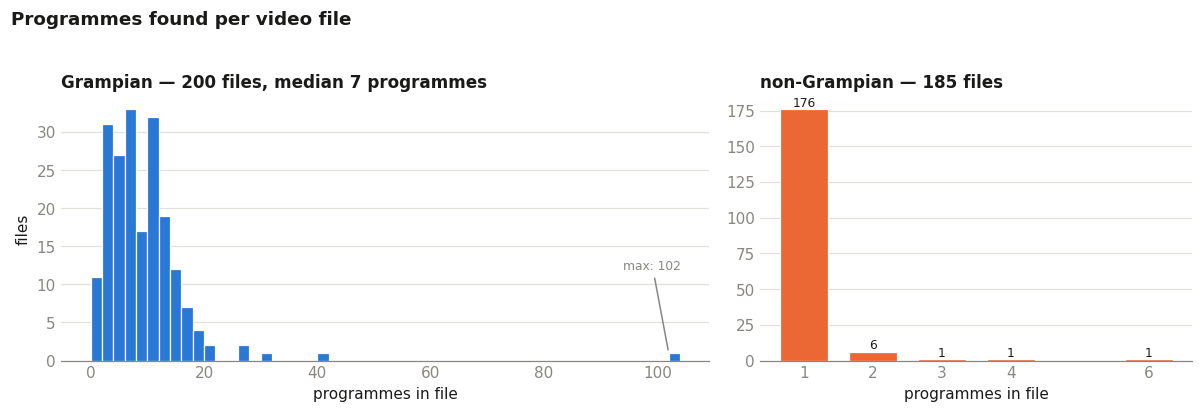

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1.5, 1]})
g = files.loc[files["collection"] == "Grampian", "n_progs"]
ng = files.loc[files["collection"] == "non-Grampian", "n_progs"]

axes[0].hist(g, bins=np.arange(0, g.max() + 3, 2), color=COLOR["Grampian"], edgecolor="white", linewidth=0.8)
axes[0].set_title(f"Grampian — {len(g)} files, median {g.median():.0f} programmes")
axes[0].set_xlabel("programmes in file"); axes[0].set_ylabel("files")
axes[0].annotate(f"max: {g.max()}", xy=(g.max(), 1), xytext=(g.max() - 8, 12), color=MUTED, fontsize=8,
                 arrowprops=dict(arrowstyle="-", color=MUTED))

vc = ng.value_counts().sort_index()
axes[1].bar(vc.index, vc.values, color=COLOR["non-Grampian"], edgecolor="white", linewidth=0.8, width=0.7)
for x, y in vc.items():
    axes[1].text(x, y + 2, str(y), ha="center", fontsize=8)
axes[1].set_title(f"non-Grampian — {len(ng)} files")
axes[1].set_xlabel("programmes in file"); axes[1].set_xticks(vc.index)
for ax in axes: clean(ax); ax.grid(axis="y", visible=True)
fig.suptitle("Programmes found per video file", x=0.01, ha="left", fontsize=12, fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

**Programme duration** — shown up to 30 min; the counts beyond that (and the very short ones) are noted on each panel.

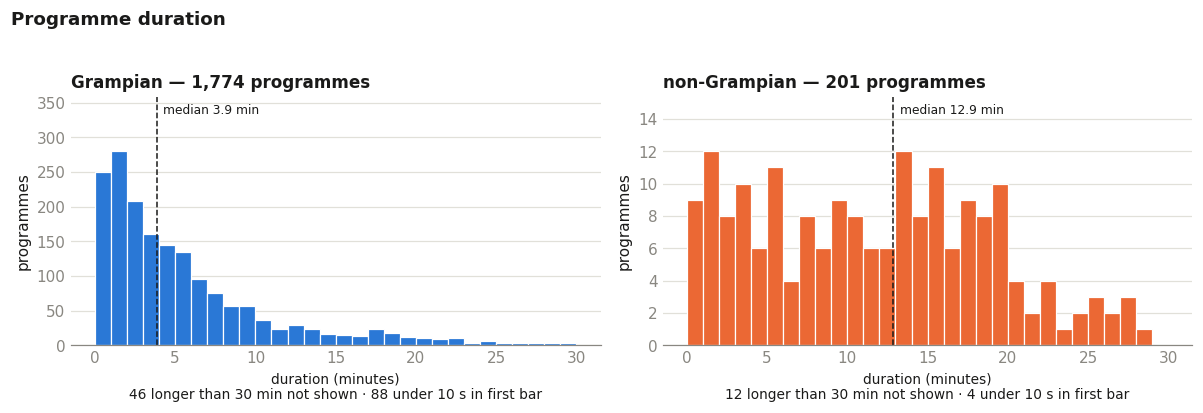

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col in zip(axes, ["Grampian", "non-Grampian"]):
    d = df.loc[df["collection"] == col, "duration_min"]
    ax.hist(d[d <= 30], bins=np.arange(0, 31, 1), color=COLOR[col], edgecolor="white", linewidth=0.8)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.22)
    top = ax.get_ylim()[1]
    ax.axvline(d.median(), color=INK, linewidth=1, linestyle="--")
    ax.text(d.median() + 0.4, top * 0.93, f"median {d.median():.1f} min", fontsize=8)
    ax.set_title(f"{col} — {len(d):,} programmes")
    ax.set_xlabel(f"duration (minutes)\n{int((d > 30).sum())} longer than 30 min not shown · {int((d < 10 / 60).sum())} under 10 s in first bar", fontsize=9)
    ax.set_ylabel("programmes")
    clean(ax); ax.grid(axis="y", visible=True)
fig.suptitle("Programme duration", x=0.01, ha="left", fontsize=12, fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

**Types and places** — most frequent values (a programme can carry several types / places, so bars count labels, not programmes).

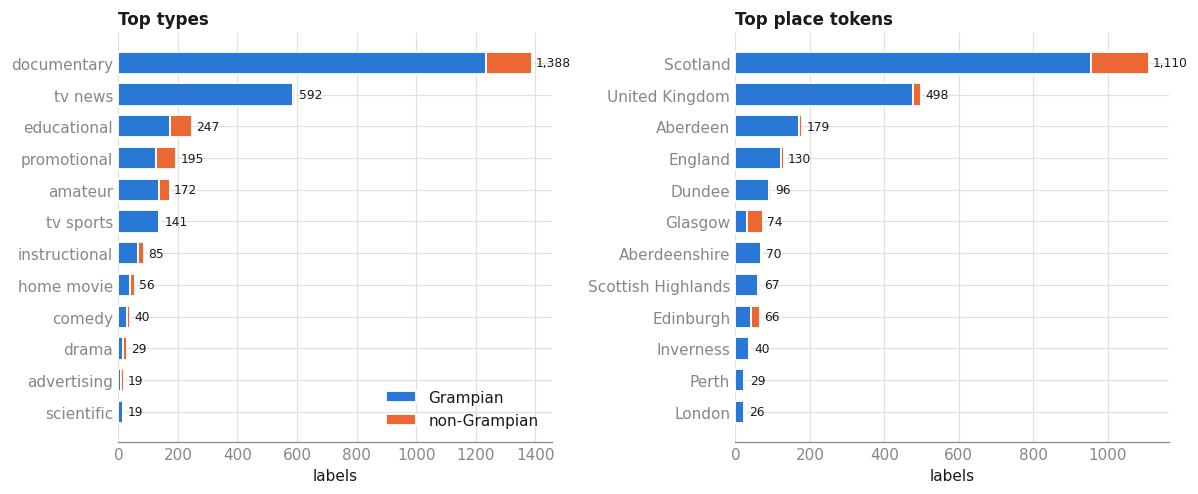

In [23]:
def label_counts(list_col):
    e = df[["collection", list_col]].explode(list_col).dropna(subset=[list_col]).reset_index(drop=True)
    return pd.crosstab(e[list_col], e["collection"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
stacked_barh(axes[0], label_counts("types_list"), top=12); axes[0].set_title("Top types")
stacked_barh(axes[1], label_counts("place_list"), top=12); axes[1].set_title("Top place tokens")
axes[1].legend_.remove()
for ax in axes: ax.set_xlabel("labels")
plt.tight_layout(); plt.show()

**Completeness** — share of programmes with the field left empty, by collection.

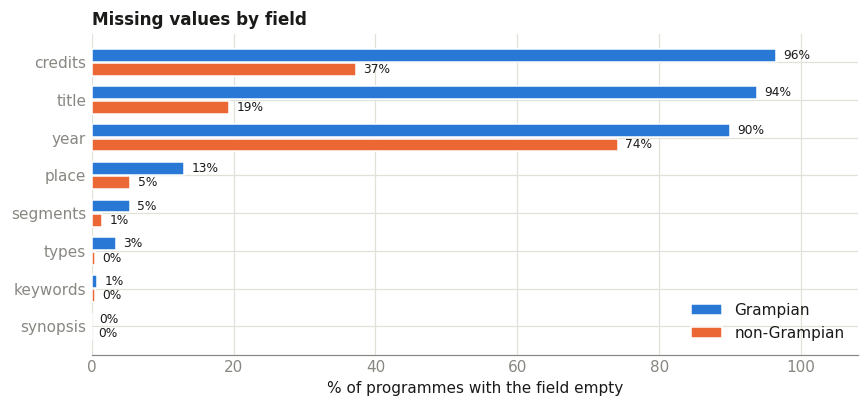

In [24]:
fields = ["title", "year", "place", "types", "segments", "credits", "keywords", "synopsis"]
miss = df.groupby("collection")[fields].apply(lambda g: g.isna().mean() * 100).T
miss = miss.sort_values("Grampian")

fig, ax = plt.subplots(figsize=(8, 3.8))
y = np.arange(len(miss)); h = 0.38
for i, col in enumerate(["Grampian", "non-Grampian"]):
    ax.barh(y + (0.5 - i) * h, miss[col], height=h - 0.04, color=COLOR[col], label=col, edgecolor="white", linewidth=1)
    for yy, v in zip(y + (0.5 - i) * h, miss[col]):
        ax.text(v + 1, yy, f"{v:.0f}%", va="center", fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(miss.index)
ax.set_xlim(0, 108); ax.set_xlabel("% of programmes with the field empty")
ax.set_title("Missing values by field")
clean(ax); ax.grid(axis="x", visible=True); ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

**Gap between consecutive programmes** in the same file (seconds). Overlaps would show as negative values.

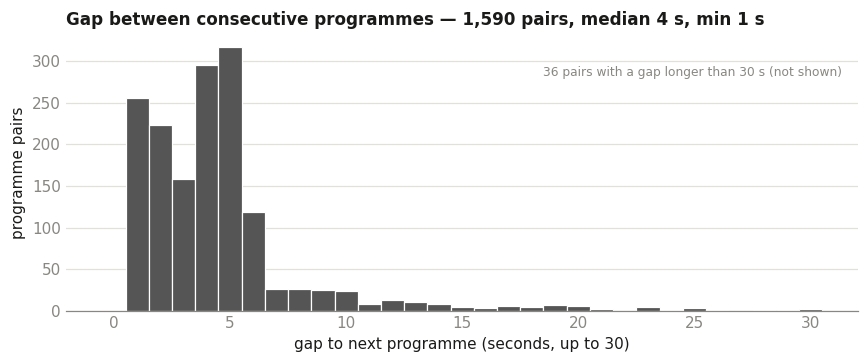

In [25]:
g = df["gap_to_next_s"].dropna()
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(g[g <= 30], bins=np.arange(-0.5, 31.5, 1), color="#555555", edgecolor="white", linewidth=0.8)
ax.set_xlabel("gap to next programme (seconds, up to 30)"); ax.set_ylabel("programme pairs")
ax.set_title(f"Gap between consecutive programmes — {len(g):,} pairs, median {g.median():.0f} s, min {g.min():.0f} s")
ax.text(0.98, 0.85, f"{int((g > 30).sum())} pairs with a gap longer than 30 s (not shown)", transform=ax.transAxes, ha="right", fontsize=8, color=MUTED)
clean(ax); ax.grid(axis="y", visible=True)
plt.tight_layout(); plt.show()

## 6. Conclusions

This notebook describes the *shape and cleanliness* of the output. It does **not** judge accuracy — no ground truth is used here.

### What is in the file
* **1,975 predicted programmes across 385 video files.** Grampian: 1,774 programmes in all 200 files (median 7 per file, mean 8.9, max 102). Non-Grampian: 201 programmes in 185 files — 176 files have a single programme, the rest 2–6. 15 of the catalogue's 200 non-Grampian films were not processed in this run.
* Programme boundaries never overlap or touch: the gap to the next programme is at least 1 s (median 4 s), consistent with the pipeline cutting out separators. 36 gaps exceed 30 s.

### Cleaning needed before analysis (roughly by impact)
1. **Segment timecodes use three styles**, two of which look identical: `HH:MM:SS` and `MM:SS:00` (minutes:seconds with a spurious `:00`). Read naively as `HH:MM:SS`, 128 programmes (6.5%) get segment timecodes far beyond their own duration (in the worst cases many hours into a programme of about an hour). §3.5 resolves this per programme (121 clean `MM:SS:00`, 7 that mix both styles inside one string — those 7 are approximate). After resolution no timecode exceeds its programme; 3 programmes still have non-ascending timecodes and 9 of 9,015 segment items do not parse.
2. **`place`** is free text: 745 distinct strings collapse to 668 order/delimiter-insensitive sets and 719 distinct tokens, and a single string mixes town, region and country. Turning it into a proper categorical needs a gazetteer; 12% of programmes have no place.
3. **Sparse fields:** `year` is empty on 88% of programmes, `title` on 86% (94% of Grampian), `credits` on 90%.
4. **`types`**: 18 labels, 63 programmes with none; the model says `tv sports` where the NLS catalogue says `tv sport`.
5. **File encoding is cp1252**, not UTF-8.
6. Trivial: `color`/`colour` (2 rows), a stray `False` in `fiction` (1 row), `year` stored as float, `batch` blank means non-Grampian (not missing data).

### Things that look odd and deserve a look at the video
* **Very short programmes:** 92 are under 10 s (88 of them Grampian) — likely fragments from over-segmentation, or separators kept as programmes.
* **Outlier files:** one Grampian file (239450428) has 102 programmes against a median of 7; the next largest have 40, 31, 27 and 26.
* **News tagging is inconsistent:** only 33% of Grampian programmes carry the `tv news` label (70% carry `documentary`); 30 of the 200 Grampian files have no `tv news` programme at all, while 6 non-Grampian programmes are labelled `tv news`.
* **Files that don't start at 00:00:00:** 179 of 385 (171 of them Grampian), typically by about 13 s — probably leader/bars, but not verified.
* **Long gaps:** the 36 gaps above 30 s (longest 601 s) could be dead air or missed programmes.

### Next steps
- Compare the predicted programme counts and boundaries against what we already have: the human annotations in `segments_true/` / `sample-11.csv` (16 files), and, for the Grampian tapes, the number of timecoded shotlist lines in the NLS metadata (`nls_metadata_analysis.ipynb`).
- Parse place data using a Gazeteer to get hierarchical place data.
- Take a look at the videos for the outliers, unusual or unexpected cases (see below).
-  Reconcile existing metadata with generated metadata to come up with an enriched version.

## 7. Human watching list

Everything the checks above found that looks **outliers, abnormal or unusual** and needs someone to look at the actual video —
collected in one place. Each item says *which file*, *where to seek*, and *why it was flagged*.

Every rule and threshold is defined in the next cell, so the list can be tightened or loosened. A flag means "worth a look",
not "wrong": some flagged cases will be perfectly fine (a long feature, a tape that really does start with 40 s of bars).
Lists are sorted with the highest priority first.

In [26]:
from IPython.display import display

# ---- thresholds (tune here) -------------------------------------------------------------
VERY_SHORT_S      = 10     # programme shorter than this (s)
VERY_LONG_S       = 3600   # programme longer than this (s) — roughly a whole tape as one programme
LONG_FOR_NEWS_S   = 1800   # Grampian programme longer than this (s), short of VERY_LONG — news items are normally short
LONG_GAP_S        = 30     # gap to the next programme longer than this (s)
LATE_START_S      = 30     # first programme of a file starts later than this (s)
NO_SEGMENTS_MIN_S = 60     # programme at least this long (s) that has no segment list
LOW_COVERAGE      = 0.85   # programmes cover less than this share of the file's span
FEW_PROGRAMMES    = 2      # Grampian tape with this many programmes or fewer
# -----------------------------------------------------------------------------------------

PRIORITY_RANK = {"high": 3, "medium": 2, "low": 1}
FLAGS = [
    # (flag, level, priority, meaning)
    ("mixed_timecodes",              "programme", "high",   "segment timecodes mix two styles inside one programme, so the times are approximate"),
    ("non_ascending_segments",       "programme", "high",   "segment timecodes go backwards"),
    ("very_long",                    "programme", "high",   f"programme longer than {VERY_LONG_S // 60} min — probably several programmes merged"),
    ("news_label_outside_grampian",  "programme", "high",   "labelled 'tv news' although the file is not in the Grampian collection"),
    ("long_gap_after",               "gap",       "high",   f"more than {LONG_GAP_S} s before the next programme — dead air or a missed programme?"),
    ("non_grampian_multi_programme", "file",      "high",   "non-Grampian file split into several programmes (the catalogue treats these as one) — real compilation or over-segmentation?"),
    ("grampian_many_programmes",     "file",      "high",   "far more programmes than a typical Grampian tape (above the upper outlier fence) — over-segmentation?"),
    ("very_short",                   "programme", "medium", f"programme shorter than {VERY_SHORT_S} s — fragment, or a separator kept as a programme?"),
    ("long_for_news",                "programme", "medium", f"Grampian programme longer than {LONG_FOR_NEWS_S // 60} min — several news items merged?"),
    ("unparsed_segment",             "programme", "medium", "segment list contains an item whose timecode could not be read"),
    ("no_segments",                  "programme", "medium", f"programme of {NO_SEGMENTS_MIN_S} s or more with no usable segment list (empty, or none of it could be parsed)"),
    ("grampian_few_programmes",      "file",      "medium", f"Grampian tape with {FEW_PROGRAMMES} programmes or fewer — items merged?"),
    ("grampian_no_news_label",       "file",      "medium", "Grampian tape in which no programme is labelled 'tv news'"),
    ("low_coverage",                 "file",      "medium", f"programmes cover less than {LOW_COVERAGE:.0%} of the file's span — a large stretch left unaccounted for"),
    ("late_first_start",             "file",      "medium", f"first programme starts after {LATE_START_S} s"),
    ("incomplete_output",            "programme", "low",    "the model returned no synopsis or no keywords"),
]
registry = pd.DataFrame(FLAGS, columns=["flag", "level", "priority", "meaning"]).set_index("flag")

def hms(s):
    s = int(s)
    return f"{s // 3600:02d}:{s % 3600 // 60:02d}:{s % 60:02d}"

def mmss(s):
    s = int(s)
    return f"{s // 60}:{s % 60:02d}"

def flag_string(flags):
    """Comma-joined names of the True flags in each row of a boolean DataFrame."""
    return flags.apply(lambda r: ", ".join(r.index[r.to_numpy()]), axis=1)

def top_priority(flags):
    rank = registry["priority"].map(PRIORITY_RANK)
    return flags.apply(lambda r: max((rank[c] for c in r.index[r.to_numpy()]), default=0), axis=1)

RANK_NAME = {v: k for k, v in PRIORITY_RANK.items()}

### 7.1 Programme-level and gap flags

One boolean per rule per programme. "Long gap" is attributed to the programme *before* the gap and listed separately (7.6),
because what needs watching there is the stretch between two programmes, not a programme.

In [27]:
is_grampian = df["collection"].eq("Grampian")
has_news = df["types_list"].apply(lambda xs: "tv news" in xs)
unparsed = df["segments_parsed"].apply(lambda xs: any(t is None for t, _ in xs))
def is_non_ascending(xs):
    secs = [t for t, _ in xs if t is not None]
    return any(b < a for a, b in zip(secs, secs[1:]))

non_ascending = df["segments_parsed"].apply(is_non_ascending)

prog_flags = pd.DataFrame({
    "mixed_timecodes":             df["segment_style"].eq("MM:SS:00 (mixed)"),
    "non_ascending_segments":      non_ascending,
    "very_long":                   df["duration_s"] > VERY_LONG_S,
    "news_label_outside_grampian": ~is_grampian & has_news,
    "long_gap_after":              df["gap_to_next_s"] > LONG_GAP_S,
    "very_short":                  df["duration_s"] < VERY_SHORT_S,
    "long_for_news":               is_grampian & (df["duration_s"] > LONG_FOR_NEWS_S) & (df["duration_s"] <= VERY_LONG_S),
    "unparsed_segment":            unparsed,
    "no_segments":                 df["segment_style"].eq("none") & (df["duration_s"] >= NO_SEGMENTS_MIN_S),
    "incomplete_output":           df["synopsis"].isna() | df["keywords"].isna(),
})
# sanity check against the QA in section 3.5
assert int(prog_flags["non_ascending_segments"].sum()) == int(qa["non_ascending"].sum())
prog_flags.sum().to_frame("programmes flagged").join(registry[["priority"]])

,programmes flagged,priority
mixed_timecodes,7,high
non_ascending_segments,3,high
very_long,6,high
news_label_outside_grampian,6,high
long_gap_after,36,high
very_short,92,medium
long_for_news,40,medium
unparsed_segment,9,medium
no_segments,16,medium
incomplete_output,17,low


### 7.2 File-level flags

Some problems belong to the whole file rather than one programme (a tape split into far too many, or far too few, programmes).
The "many programmes" fence is the usual upper outlier fence (Q3 + 1.5 × IQR) computed on the Grampian files.

In [28]:
f = df.groupby("dod").agg(
    collection=("collection", "first"),
    n_progs=("prog", "size"),
    first_start_s=("start_s", "min"),
    last_end_s=("end_s", "max"),
    covered_s=("duration_s", "sum"),
    any_news=("types_list", lambda s: any("tv news" in xs for xs in s)),
)
f["coverage"] = f["covered_s"] / f["last_end_s"]

g = f.loc[f["collection"] == "Grampian", "n_progs"]
q1, q3 = g.quantile([0.25, 0.75])
many_fence = q3 + 1.5 * (q3 - q1)
print(f"Grampian programmes per file: Q1={q1:.0f}, Q3={q3:.0f} → 'many' fence = more than {many_fence:.1f}")

file_flags = pd.DataFrame({
    "non_grampian_multi_programme": (f["collection"] == "non-Grampian") & (f["n_progs"] > 1),
    "grampian_many_programmes":     (f["collection"] == "Grampian") & (f["n_progs"] > many_fence),
    "grampian_few_programmes":      (f["collection"] == "Grampian") & (f["n_progs"] <= FEW_PROGRAMMES),
    "grampian_no_news_label":       (f["collection"] == "Grampian") & ~f["any_news"],
    "low_coverage":                 f["coverage"] < LOW_COVERAGE,
    "late_first_start":             f["first_start_s"] > LATE_START_S,
})
file_flags.sum().to_frame("files flagged").join(registry[["priority"]])

Grampian programmes per file: Q1=4, Q3=11 → 'many' fence = more than 21.5


,files flagged,priority
non_grampian_multi_programme,9,high
grampian_many_programmes,5,high
grampian_few_programmes,27,medium
grampian_no_news_label,30,medium
low_coverage,3,medium
late_first_start,3,medium


### 7.3 How much there is to watch

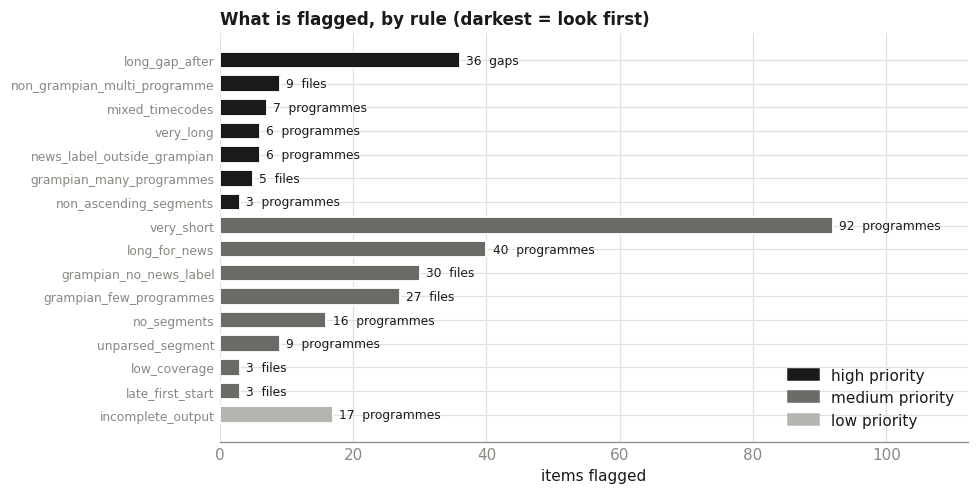

172 programmes, 36 gaps and 63 files are flagged (out of 1,975 programmes and 385 files).


In [29]:
counts = pd.concat([
    prog_flags.sum().rename("n"),
    file_flags.sum().rename("n"),
]).to_frame().join(registry[["level", "priority"]])
counts["unit"] = counts["level"].map({"programme": "programmes", "gap": "gaps", "file": "files"})
counts = counts.sort_values(["priority", "n"], key=lambda c: c.map(PRIORITY_RANK) if c.name == "priority" else c, ascending=[False, False])

TIER = {"high": "#1a1a19", "medium": "#6b6a66", "low": "#b5b4ae"}   # dark = look first
fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(counts))[::-1]
ax.barh(y, counts["n"], color=[TIER[p] for p in counts["priority"]], height=0.7, edgecolor="white", linewidth=1.2)
for yy, (n, unit) in zip(y, counts[["n", "unit"]].itertuples(index=False)):
    ax.text(n + counts["n"].max() * 0.01, yy, f"{n}  {unit}", va="center", fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(counts.index, fontsize=8)
ax.set_xlim(0, counts["n"].max() * 1.22); ax.set_xlabel("items flagged")
ax.set_title("What is flagged, by rule (darkest = look first)")
clean(ax); ax.grid(axis="x", visible=True)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=TIER[k], label=f"{k} priority") for k in ["high", "medium", "low"]], frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

n_prog_rows = int(prog_flags.drop(columns="long_gap_after").any(axis=1).sum())
print(f"{n_prog_rows} programmes, {int(prog_flags['long_gap_after'].sum())} gaps and {int(file_flags.any(axis=1).sum())} files are flagged "
      f"(out of {len(df):,} programmes and {f.shape[0]} files).")

### 7.4 Files to watch

One row per file. `flagged_programmes` counts how many of its programmes also appear in the programme list below.
`first_start` and `coverage` (share of the file's span that programmes account for) are there to help spot-check quickly.

In [30]:
files_watch = f.loc[file_flags.any(axis=1), ["collection", "n_progs", "first_start_s", "coverage"]].copy()
files_watch["priority"] = top_priority(file_flags.loc[files_watch.index]).map(RANK_NAME)
files_watch["flags"] = flag_string(file_flags.loc[files_watch.index])
prog_flag_any = prog_flags.drop(columns="long_gap_after").any(axis=1)
files_watch["flagged_programmes"] = df.loc[prog_flag_any].groupby("dod").size().reindex(files_watch.index).fillna(0).astype(int)
files_watch["first_start"] = files_watch["first_start_s"].map(hms)
files_watch["coverage"] = (files_watch["coverage"] * 100).round(0).astype(int).astype(str) + "%"
files_watch = (files_watch.assign(_r=files_watch["priority"].map(PRIORITY_RANK))
               .sort_values(["_r", "n_progs"], ascending=[False, False]).drop(columns=["_r", "first_start_s"])
               .reset_index())
with pd.option_context("display.max_rows", None, "display.max_colwidth", 120, "display.width", 220):
    display(files_watch[["dod", "collection", "priority", "n_progs", "first_start", "coverage", "flagged_programmes", "flags"]])

,dod,collection,priority,n_progs,first_start,coverage,flagged_programmes,flags
0,239450428,Grampian,high,102,00:00:03,92%,1,grampian_many_programmes
1,140179407,Grampian,high,40,00:00:07,95%,1,grampian_many_programmes
2,234773769,Grampian,high,31,00:00:01,97%,1,grampian_many_programmes
3,234552207,Grampian,high,27,00:00:05,98%,0,grampian_many_programmes
4,250551694,Grampian,high,26,00:00:02,98%,1,"grampian_many_programmes, grampian_no_news_label"
5,109614369,non-Grampian,high,6,00:00:00,99%,0,non_grampian_multi_programme
6,255686261,non-Grampian,high,4,00:00:00,84%,3,"non_grampian_multi_programme, low_coverage"
7,138690154,non-Grampian,high,3,00:00:00,100%,0,non_grampian_multi_programme
8,94815554,non-Grampian,high,2,00:00:00,99%,0,non_grampian_multi_programme
9,99397012,non-Grampian,high,2,00:00:00,100%,0,non_grampian_multi_programme


### 7.5 Programmes to watch

One row per flagged programme. **`seek_to`** is where the programme starts in the file (`HH:MM:SS`), `duration` is `m:ss`, and
`programme` reads "number in file / programmes in file". `what` is the model's own title or summary, so you can tell at a glance
what the pipeline *thinks* it is. Long gaps are not repeated here (see 7.6).

In [31]:
pf = prog_flags.drop(columns="long_gap_after")
pw = df.loc[pf.any(axis=1), ["dod", "collection", "prog_no", "start_s", "duration_s", "title", "summary"]].copy()
pw["n_in_file"] = df.groupby("dod")["prog"].transform("size").loc[pw.index]
pw["priority"] = top_priority(pf.loc[pw.index]).map(RANK_NAME)
pw["flags"] = flag_string(pf.loc[pw.index])
pw["programme"] = pw["prog_no"].astype(str) + "/" + pw["n_in_file"].astype(str)
pw["seek_to"] = pw["start_s"].map(hms)
pw["duration"] = pw["duration_s"].map(mmss)
pw["what"] = pw["title"].where(pw["title"].notna(), pw["summary"]).str.slice(0, 110)
pw = (pw.assign(_r=pw["priority"].map(PRIORITY_RANK))
        .sort_values(["_r", "dod", "prog_no"], ascending=[False, True, True]).drop(columns="_r"))
with pd.option_context("display.max_rows", None, "display.max_colwidth", 120, "display.width", 240):
    display(pw[["dod", "collection", "priority", "programme", "seek_to", "duration", "flags", "what"]].reset_index(drop=True))

,dod,collection,priority,programme,seek_to,duration,flags,what
0,91790259,non-Grampian,high,1/1,00:00:00,3:55,news_label_outside_grampian,Churchill Receives Freedom of Perth
1,102051358,non-Grampian,high,1/1,00:00:00,16:31,news_label_outside_grampian,Royal Highland Show Ayr 1958
2,116943369,non-Grampian,high,1/1,00:00:00,2:16,news_label_outside_grampian,"Newsreel footage of a Campaign for Nuclear Disarmament rally in Dumbarton, showing heavy police presence, prot"
3,117622594,non-Grampian,high,1/1,00:00:02,1:43,news_label_outside_grampian,"A packed hillside audience watches a rustic open-air folk play with traditional dances, then a boxing bout is"
4,139329391,Grampian,high,1/1,00:00:22,61:16,very_long,A television news report chronicling the disruption caused by heavy snow and freezing weather across the Scott
5,139329395,Grampian,high,1/1,00:00:05,60:55,very_long,A Scottish television feature in which officials tour an offshore survival training centre and watch pool-base
6,139329397,Grampian,high,1/1,00:00:00,61:25,very_long,"A regional Scottish television magazine covering late-life university graduates, security worries over politic"
7,139329399,Grampian,high,6/7,00:23:50,39:14,"mixed_timecodes, long_for_news","A Scottish current-affairs broadcast combining winter footage of the Culloden battlefield, David Steel's speec"
8,139329421,Grampian,high,2/3,00:57:26,4:39,non_ascending_segments,"Archival colour footage of a Scottish regional index office where clerks type, file and cross-reference record"
9,139439525,Grampian,high,1/2,00:00:18,60:15,very_long,A documentary tour of Scottish performing arts featuring a new theatre season at Puddockford in Perth interspe


### 7.6 Gaps to watch

Stretches between two consecutive programmes in the same file that are longer than the threshold. Watch from `gap_from` to `gap_to`:
is it dead air / bars / a break, or is a programme missing?

In [32]:
gw = df.loc[prog_flags["long_gap_after"], ["dod", "collection", "prog_no", "end_s", "gap_to_next_s"]].copy()
gw["after_programme"] = gw["prog_no"]
gw["gap_from"] = gw["end_s"].map(hms)
gw["gap_to"] = (gw["end_s"] + gw["gap_to_next_s"]).map(hms)
gw["gap"] = gw["gap_to_next_s"].map(mmss)
gw = gw.sort_values("gap_to_next_s", ascending=False)
with pd.option_context("display.max_rows", None, "display.width", 200):
    display(gw[["dod", "collection", "after_programme", "gap_from", "gap_to", "gap"]].reset_index(drop=True))

,dod,collection,after_programme,gap_from,gap_to,gap
0,139482721,Grampian,2,00:09:14,00:19:15,10:01
1,255686261,non-Grampian,1,00:00:09,00:05:37,5:28
2,139439581,Grampian,15,00:55:57,01:01:10,5:13
3,141348991,Grampian,14,00:57:10,01:01:27,4:17
4,139930701,Grampian,7,00:49:49,00:54:00,4:11
5,141349019,Grampian,2,00:12:39,00:16:44,4:05
6,141339773,Grampian,15,00:58:57,01:02:34,3:37
7,142279834,Grampian,11,00:59:46,01:02:49,3:03
8,139482690,Grampian,10,00:58:23,01:01:03,2:40
9,139439547,Grampian,3,00:51:38,00:53:59,2:21


### 7.7 Films not processed in this run

The predictions cover 385 files; the NLS catalogue has 400. This lists the catalogue films that are **not in this run**,
and checks the other direction too. It reads the catalogue from the same RDS mount as `nls_metadata_analysis.ipynb`
and is skipped (with a message) if the mount is not available.

In [33]:
NLS_METADATA_DIR = Path("/mnt/rds_issa/data/input/NLS/batch2/NLS Metadata")   # same mount as nls_metadata_analysis.ipynb
try:
    clips = pd.read_csv(NLS_METADATA_DIR / "Clips_Table.csv", encoding="cp1252")[["DODfilenameprefix", "ref no"]]
    films = pd.read_csv(NLS_METADATA_DIR / "FILMS.csv", encoding="cp1252")[["ref no", "title", "dateOfReleaseYYYY", "timing", "type"]]
except OSError:   # covers a missing folder and an unreachable mount
    print(f"NLS metadata not reachable at {NLS_METADATA_DIR} — skipping. (Needs the RDS mount.)")
else:
    catalogue = clips.merge(films, on="ref no", how="inner")
    catalogue["collection"] = np.where(catalogue["type"].fillna("").str.contains("tv news"), "Grampian", "non-Grampian")
    predicted = set(df["dod"])
    missing = catalogue[~catalogue["DODfilenameprefix"].isin(predicted)]
    extra = predicted - set(catalogue["DODfilenameprefix"])
    print(f"catalogue files: {len(catalogue)} | with predictions: {len(catalogue) - len(missing)} | without: {len(missing)}"
          f" ({missing['collection'].value_counts().to_dict()})")
    print(f"prediction files not found in the catalogue: {len(extra)}")
    with pd.option_context("display.max_rows", None, "display.max_colwidth", 70, "display.width", 200):
        display(missing.sort_values("timing")[["DODfilenameprefix", "ref no", "title", "dateOfReleaseYYYY", "timing", "collection"]].reset_index(drop=True))

NLS metadata not reachable at /mnt/rds_issa/data/input/NLS/batch2/NLS Metadata — skipping. (Needs the RDS mount.)


## 8. Which files to watch first

Section 7 lists *everything* flagged. A human reviewer needs a short order of play, so the files are **ranked** — and the aim is to
*learn as much as possible from the first few hours of watching*, not simply to surface the messiest files.

* **Score** (shown for information) = sum of the priority weights (high 3, medium 2, low 1) of every *distinct* rule that fires in the file.
* **Order** is chosen greedily: at each step take the file that adds the most **not-yet-seen problem types**. Each rule gets its first
  few example files at full weight (**three** for high-priority rules, two for medium, one for low); after that a repeat is worth only 30%. Without this, common weak flags (like very short programmes)
  crowd out rarer, more informative ones (a compilation split into parts, a 102-programme tape).
* `shows_first` lists the problem types the file was picked to illustrate — the reason it sits where it does.
* Ties: higher score, then more flagged items, then more programmes.

`Top 5`, `Top 10`, `Top 20` label the rank bands (a file in the top 5 is labelled `Top 5`, the next five `Top 10`, and so on).

In [34]:
weight = registry["priority"].map(PRIORITY_RANK)
CODE = {3: "P1", 2: "P2", 1: "P3"}            # priority codes used in the spreadsheet: P1 = high, P2 = medium, P3 = low

by_file = df["dod"]
prog_counts = prog_flags.groupby(by_file).sum()                       # per file: how many programmes / gaps trip each programme-level rule
present = pd.concat([file_flags, prog_counts.gt(0)], axis=1).reindex(f.index).fillna(False).astype(bool)

items_to_check = (
    prog_flags.drop(columns="long_gap_after").any(axis=1).groupby(by_file).sum()
    + prog_flags["long_gap_after"].groupby(by_file).sum()
).reindex(f.index).fillna(0).astype(int)

def flags_summary(dod):
    row = present.loc[dod]
    names = sorted(row.index[row], key=lambda c: (-weight[c], c))
    return "; ".join(c if registry.loc[c, "level"] == "file" else f"{c} x{int(prog_counts.loc[dod, c])}" for c in names)

def look_at(dod, limit=6):
    """Where to seek in this file: flagged programme start times and long-gap windows, in time order."""
    items = []
    for r in pw.loc[pw["dod"] == dod].itertuples():
        items.append((r.start_s, f"{r.seek_to} {r.flags.replace(', ', '+')}"))
    for r in gw.loc[gw["dod"] == dod].itertuples():
        items.append((r.end_s, f"{r.gap_from}→{r.gap_to} long gap ({r.gap})"))
    if not items:
        return "whole file (file-level flag)"
    items.sort()
    shown = " | ".join(t for _, t in items[:limit])
    return shown + (f" | +{len(items) - limit} more" if len(items) > limit else "")

cand = pd.DataFrame({
    "collection": f["collection"],
    "n_programmes": f["n_progs"],
    "score": present.mul(weight.reindex(present.columns), axis=1).sum(axis=1).astype(int),
    "items_to_check": items_to_check,
    "priority_code": present.apply(lambda r: CODE[max((PRIORITY_RANK[registry.loc[c, "priority"]] for c in r.index[r]), default=1)], axis=1),
})
cand = cand[cand["score"] > 0]
flags_of = {int(d): list(present.columns[present.loc[d].to_numpy()]) for d in cand.index}

EXEMPLARS = {"high": 3, "medium": 2, "low": 1}   # each rule gets its first N example files at full weight (N by priority) ...
REPEAT_CREDIT = 0.3    # ... after that a repeat is worth only this fraction
seen = {c: 0 for c in present.columns}
quota = {c: EXEMPLARS[registry.loc[c, "priority"]] for c in present.columns}
order, first_shows = [], {}
remaining = set(flags_of)
while remaining:
    def gain(d):
        return sum(weight[c] * (1.0 if seen[c] < quota[c] else REPEAT_CREDIT) for c in flags_of[d])
    best = max(remaining, key=lambda d: (gain(d), cand.loc[d, "score"], cand.loc[d, "items_to_check"], cand.loc[d, "n_programmes"], -d))
    first_shows[best] = sorted((c for c in flags_of[best] if seen[c] < quota[c]), key=lambda c: (-weight[c], c))
    for c in flags_of[best]:
        seen[c] += 1
    order.append(best)
    remaining.remove(best)

ranking = cand.loc[order].rename_axis("dod").reset_index()
ranking.insert(0, "rank", ranking.index + 1)
ranking["look_in"] = pd.cut(ranking["rank"], [0, 5, 10, 20, np.inf], labels=["Top 5", "Top 10", "Top 20", "After"]).astype(str)
ranking["shows_first"] = ranking["dod"].map(lambda d: "; ".join(first_shows[int(d)]))
ranking["flags"] = ranking["dod"].map(flags_summary)
ranking["look_at"] = ranking["dod"].map(look_at)

print(f"{len(ranking)} of {len(f)} files raise at least one flag of any kind; "
      f"priority codes: {ranking['priority_code'].value_counts().to_dict()}")
with pd.option_context("display.max_rows", None, "display.max_colwidth", 150, "display.width", 260):
    display(ranking.loc[ranking["rank"] <= 20, ["rank", "look_in", "priority_code", "dod", "collection", "n_programmes", "score", "shows_first", "flags", "look_at"]])

154 of 385 files raise at least one flag of any kind; priority codes: {'P2': 90, 'P1': 64}


,rank,look_in,priority_code,dod,collection,n_programmes,score,shows_first,flags,look_at
0,1,Top 5,P1,139329399,Grampian,7,12,long_gap_after; mixed_timecodes; long_for_news; unparsed_segment; very_short,long_gap_after x1; mixed_timecodes x1; long_for_news x1; unparsed_segment x1; very_short x1,00:16:28 unparsed_segment | 00:23:50 mixed_timecodes+long_for_news | 01:03:04→01:03:40 long gap (0:36) | 01:03:40 very_short
1,2,Top 5,P1,255686261,non-Grampian,4,11,long_gap_after; non_grampian_multi_programme; low_coverage; very_short; incomplete_output,long_gap_after x2; non_grampian_multi_programme; low_coverage; very_short x3; incomplete_output x1,00:00:00 very_short | 00:00:09→00:05:37 long gap (5:28) | 00:05:37 very_short | 00:43:15→00:44:49 long gap (1:34) | 00:44:49 very_short+incomplete...
2,3,Top 5,P1,139482721,Grampian,7,9,long_gap_after; grampian_no_news_label; long_for_news; low_coverage,long_gap_after x1; grampian_no_news_label; long_for_news x1; low_coverage,00:09:14→00:19:15 long gap (10:01) | 00:29:34 long_for_news
3,4,Top 5,P1,139439525,Grampian,2,10,very_long; grampian_few_programmes; grampian_no_news_label,very_long x1; grampian_few_programmes; grampian_no_news_label; very_short x1; incomplete_output x1,00:00:18 very_long | 01:00:35 very_short+incomplete_output
4,5,Top 5,P1,139482785,Grampian,10,7,mixed_timecodes; no_segments,mixed_timecodes x1; no_segments x1; very_short x1,00:00:09 mixed_timecodes | 00:18:53 no_segments | 01:00:19 very_short
5,6,Top 10,P1,140179429,Grampian,2,7,very_long; grampian_few_programmes,very_long x1; grampian_few_programmes; very_short x1,00:00:12 very_long | 01:02:27 very_short
6,7,Top 10,P1,250551694,Grampian,26,7,grampian_many_programmes; no_segments,grampian_many_programmes; grampian_no_news_label; no_segments x1,01:27:37 no_segments
7,8,Top 10,P1,139329421,Grampian,3,10,non_ascending_segments,long_gap_after x1; non_ascending_segments x1; long_for_news x1; very_short x1,00:00:05 long_for_news | 00:57:26 non_ascending_segments | 01:02:05→01:02:56 long gap (0:51) | 01:02:56 very_short
8,9,Top 10,P1,234773769,Grampian,31,8,grampian_many_programmes,grampian_many_programmes; long_gap_after x1; very_short x1,01:49:27→01:49:59 long gap (0:32) | 01:49:59 very_short
9,10,Top 10,P1,139482709,Grampian,1,7,very_long,very_long x1; grampian_few_programmes; grampian_no_news_label,00:00:00 very_long


## 9. Export to a spreadsheet

Writes one Excel workbook for the human reviewers, with these sheets:

| sheet | contents |
|---|---|
| `README` | how to read it: priority codes, tiers, every flag and what it means, the thresholds used |
| `top_20_files` | the 20 files to watch first, ranked, with where to seek and blank columns for the reviewer's verdict |
| `all_flagged_files` | every file that raised any flag, with its rank |
| `programmes` | every flagged programme, with `seek_to` and its file's rank |
| `gaps` | every gap over the threshold, with `gap_from` / `gap_to` |
| `not_processed` | catalogue films not processed in this run (only if the RDS mount is available) |

Priority codes: **P1** = high, **P2** = medium, **P3** = low. The `reviewer`, `verdict` and `notes` columns are left empty on purpose.

The file is written **outside the repo tree** (`<repo-root>/data/output/ws1/`, which is git-ignored): it contains the model's own text about
archive films, so it should not be committed by accident. Move it wherever the reviewers need it.

In [35]:
from datetime import date

EXPORT_PATH = Path("../../../data/output/ws1/predictions_watchlist.xlsx")   # <repo-root>/data/output/ws1/ — git-ignored
EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

rank_of = ranking.set_index("dod")[["rank", "look_in"]]
pcode = lambda p: CODE[PRIORITY_RANK[p]]
REVIEW_COLS = ["reviewer", "verdict", "notes"]

# --- sheets ---------------------------------------------------------------------------
top_files = ranking.loc[ranking["rank"] <= 20, ["rank", "look_in", "priority_code", "dod", "collection", "n_programmes",
                                                 "score", "shows_first", "flags", "look_at"]].copy()
for c in REVIEW_COLS:
    top_files[c] = ""

all_files = ranking[["rank", "look_in", "priority_code", "dod", "collection", "n_programmes", "score", "items_to_check", "shows_first", "flags", "look_at"]].copy()

progs_sheet = pw.reset_index(drop=True).copy()
progs_sheet["priority_code"] = progs_sheet["priority"].map(pcode)
progs_sheet = progs_sheet.join(rank_of, on="dod").rename(columns={"rank": "file_rank", "look_in": "file_look_in"})
progs_sheet["_p"] = progs_sheet["priority_code"].map({"P1": 1, "P2": 2, "P3": 3})
progs_sheet = progs_sheet.sort_values(["_p", "file_rank", "dod", "prog_no"])[
    ["priority_code", "file_rank", "file_look_in", "dod", "collection", "programme", "seek_to", "duration", "flags", "what"]]
for c in REVIEW_COLS:
    progs_sheet[c] = ""

gaps_sheet = gw.reset_index(drop=True).copy()
gaps_sheet["priority_code"] = pcode("high")
gaps_sheet = gaps_sheet.join(rank_of, on="dod").rename(columns={"rank": "file_rank", "look_in": "file_look_in"})
gaps_sheet = gaps_sheet.sort_values(["file_rank", "dod", "after_programme"])[
    ["priority_code", "file_rank", "file_look_in", "dod", "collection", "after_programme", "gap_from", "gap_to", "gap"]]
for c in REVIEW_COLS:
    gaps_sheet[c] = ""

readme_rows = [
    ("Pipeline predictions — human watching list", ""),
    ("generated", str(date.today())),
    ("source", str(PREDICTIONS_CSV.name)),
    ("", ""),
    ("priority codes", "P1 = high (look first) · P2 = medium · P3 = low"),
    ("look_in", "Top 5 / Top 10 / Top 20 = the file's rank band (a Top 5 file is also inside the top 10 and 20); After = ranked 21 or lower"),
    ("rank / score", "Score = sum of priority weights (high 3, medium 2, low 1) of each DISTINCT rule that fires in the file. Rank is diversity-aware: each next file is the one adding the most not-yet-seen problem types (each rule's first 3 / 2 / 1 example files — high / medium / low — count in full, repeats 30%)"),
    ("shows_first", "the problem types this file was picked to illustrate — the reason for its rank"),
    ("seek_to / gap_from / gap_to", "HH:MM:SS from the start of the video file"),
    ("reviewer / verdict / notes", "left blank for the person watching (suggested verdicts: boundaries OK · too many programmes · too few · wrong split at hh:mm:ss · other)"),
    ("caveat", "A flag means 'worth a look', not 'wrong'. Nothing here has been checked against the video yet."),
    ("", ""),
    ("FLAG", "PRIORITY · LEVEL · MEANING"),
]
readme_rows += [(name, f"{pcode(r.priority)} · {r.level} · {r.meaning}") for name, r in registry.iterrows()]
readme_rows += [("", ""), ("THRESHOLD", "VALUE")] + [
    ("VERY_SHORT_S", VERY_SHORT_S), ("VERY_LONG_S", VERY_LONG_S), ("LONG_FOR_NEWS_S", LONG_FOR_NEWS_S), ("LONG_GAP_S", LONG_GAP_S),
    ("LATE_START_S", LATE_START_S), ("NO_SEGMENTS_MIN_S", NO_SEGMENTS_MIN_S), ("LOW_COVERAGE", LOW_COVERAGE),
    ("FEW_PROGRAMMES", FEW_PROGRAMMES), ("'many programmes' fence (Grampian)", round(float(many_fence), 1)),
]
readme = pd.DataFrame(readme_rows, columns=["item", "explanation"])

sheets = {"README": readme, "top_20_files": top_files, "all_flagged_files": all_files, "programmes": progs_sheet, "gaps": gaps_sheet}
if "missing" in globals():
    nop = missing.sort_values("timing")[["DODfilenameprefix", "ref no", "title", "dateOfReleaseYYYY", "timing", "collection"]].copy()
    nop["note"] = "not processed in this run"
    for c in REVIEW_COLS:
        nop[c] = ""
    sheets["not_processed"] = nop

# --- write + tidy the formatting -------------------------------------------------------
from openpyxl.styles import Alignment, Font, PatternFill

FILL = {"P1": "F8C9C4", "P2": "FCE7B0", "P3": "E4E3DE"}
WRAP = {"flags", "shows_first", "look_at", "what", "meaning", "explanation", "notes", "title", "note"}

with pd.ExcelWriter(EXPORT_PATH, engine="openpyxl") as xw:
    for name, sheet in sheets.items():
        sheet.to_excel(xw, sheet_name=name, index=False)
        ws = xw.sheets[name]
        header = [c.value for c in ws[1]]
        for cell in ws[1]:
            cell.font = Font(bold=True)
        ws.freeze_panes = "A2"
        ws.auto_filter.ref = ws.dimensions
        for j, col in enumerate(header, start=1):
            letter = ws.cell(row=1, column=j).column_letter
            longest = max([len(str(col))] + [len(str(v)) for v in sheet[col].head(200)])
            ws.column_dimensions[letter].width = min(max(10, longest + 2), 70 if col in WRAP else 32)
            for row in ws.iter_rows(min_row=2, min_col=j, max_col=j):
                for cell in row:
                    cell.alignment = Alignment(wrap_text=col in WRAP, vertical="top")
                    if col == "priority_code" and cell.value in FILL:
                        cell.fill = PatternFill("solid", fgColor=FILL[cell.value])

print("wrote", EXPORT_PATH.resolve())

wrote /home/daniel/Projects/issa/data/output/ws1/predictions_watchlist.xlsx


In [36]:
# read the workbook back to confirm what was written
back = pd.read_excel(EXPORT_PATH, sheet_name=None)
pd.Series({name: f"{len(s)} rows × {s.shape[1]} columns" for name, s in back.items()}, name="sheet")

README                 40 rows × 2 columns
top_20_files          20 rows × 13 columns
all_flagged_files    154 rows × 11 columns
programmes           172 rows × 13 columns
gaps                  36 rows × 12 columns
Name: sheet, dtype: str

### Numbers behind the plain-language takeaways

In [37]:
n_files = len(f)
no_flag_files = n_files - len(ranking)
prog_units = int(prog_flag_any.sum())
print(f"files: {n_files} | with no flag of any kind: {no_flag_files} ({no_flag_files / n_files:.0%}) | flagged: {len(ranking)} ({len(ranking) / n_files:.0%})")
print(f"programmes: {len(df):,} | with a programme-level flag: {prog_units} ({prog_units / len(df):.1%}) | no such flag: {len(df) - prog_units:,} ({1 - prog_units / len(df):.1%})")
print("priority of flagged files:", ranking["priority_code"].value_counts().to_dict())

print("\nshare of each file's span that programmes account for (coverage):",
      f["coverage"].quantile([0, 0.05, 0.25, 0.5]).round(3).to_dict(),
      "| files below 95%:", int((f["coverage"] < 0.95).sum()))
print("non-Grampian files with a single programme:", int(((f["collection"] == "non-Grampian") & (f["n_progs"] == 1)).sum()),
      "of", int((f["collection"] == "non-Grampian").sum()))

print("\ngenerated text present — summary: {:.1%}, synopsis: {:.1%}, keywords: {:.1%}".format(
    df["summary"].notna().mean(), df["synopsis"].notna().mean(), df["keywords"].notna().mean()))
print("labels present — type: {:.0%}, place: {:.0%}, year: {:.0%}, title: {:.0%}".format(
    (df["n_types"] > 0).mean(), df["place"].notna().mean(), df["year"].notna().mean(), df["title"].notna().mean()))

top20 = ranking[ranking["rank"] <= 20]
print("\ntop 20 files —", top20["collection"].value_counts().to_dict(), "| priority:", top20["priority_code"].value_counts().to_dict())
kinds = top20["flags"].str.split("; ").explode().str.replace(r" x\d+$", "", regex=True).value_counts()
print("flags present in the top 20 (files):", kinds.to_dict())

files: 385 | with no flag of any kind: 231 (60%) | flagged: 154 (40%)
programmes: 1,975 | with a programme-level flag: 172 (8.7%) | no such flag: 1,803 (91.3%)
priority of flagged files: {'P2': 90, 'P1': 64}

share of each file's span that programmes account for (coverage): {0.0: 0.821, 0.05: 0.962, 0.25: 0.986, 0.5: 0.996} | files below 95%: 15
non-Grampian files with a single programme: 176 of 185

generated text present — summary: 100.0%, synopsis: 99.9%, keywords: 99.2%
labels present — type: 97%, place: 88%, year: 12%, title: 14%

top 20 files — {'Grampian': 16, 'non-Grampian': 4} | priority: {'P1': 19, 'P2': 1}
flags present in the top 20 (files): {'very_short': 13, 'long_gap_after': 7, 'long_for_news': 4, 'incomplete_output': 4, 'grampian_no_news_label': 4, 'grampian_few_programmes': 4, 'mixed_timecodes': 3, 'very_long': 3, 'no_segments': 3, 'grampian_many_programmes': 3, 'non_ascending_segments': 3, 'unparsed_segment': 2, 'non_grampian_multi_programme': 2, 'low_coverage': 2, 'l

## 10. Takeaways in plain language

*For readers who don't need the code. Every number below is printed by the cells above.*

**What this is.** The first full run of the pipeline over 385 archive videos (all 200 Grampian news tapes and 185 of the 200 other films). For each video it proposes where the separate programmes start and end, and writes a title, summary, description, keywords, place, year and type for each one — 1,975 programmes in all. This notebook looks at *what came out*; it does not check it against the footage.

### What we can reasonably say from the data alone
* **It ran at scale and treated the two collections as we expected.** Grampian tapes were split into many programmes (typically 7 per tape); the other films almost always came out as a single programme (176 of 185). That matches what the NLS catalogue's own structure suggested, but a plausible pattern is not proof that the splits are right.
* **Nearly the whole of each video is accounted for.** In a typical file the proposed programmes cover 99–100% of it, and only 15 files fall below 95% (the lowest is 82%). Programmes never overlap and are separated by a few seconds (typically 4) — consistent with the pipeline finding the breaks between programmes.
* **The written descriptions are essentially complete.** Almost every programme has a summary, description and keywords (99–100%), and most have a type (97%) and a place (88%). Very few have a year (12%) or a title (14%) — the pipeline mostly leaves those blank.
* **Most files raise no red flag, but that is not the same as "correct".** 231 of 385 files (60%) trip none of our checks; 154 trip at least one (64 of them a high-priority one). Only 8.7% of programmes are flagged individually.

### What this analysis cannot tell us
Whether a boundary falls in the right place, whether a summary is true, or whether a place or year is right. Our checks only spot things that look odd. **A flag is a reason to look, not a measured error rate.**

### What needs a person to watch
Everything is in the spreadsheet (see section 9), ordered so the first few hours of watching teach us the most. In brief:
* **Where the cuts are** on the top 5 / 10 / 20 files: tapes cut into far too many pieces (one has 102 programmes; the typical tape has 7), tapes cut into too few, 92 programmes shorter than 10 seconds, 6 programmes longer than an hour, and 36 unexplained gaps of over 30 seconds.
* **Films the catalogue treats as one programme that the pipeline split into several** (9 films): is each a genuine compilation of separate programmes, or over-splitting? This is the open definition question we still need NLS's view on.
* **Whether the labels can be trusted.** Only a third of Grampian programmes are labelled as news (most are labelled "documentary"), and 30 news tapes have no news label at all.
* **Whether the descriptions, places and years are factually right** — nothing here checks that. Watch a few *unflagged* files as well, as a control.

### What this suggests about the first pass (provisionally)
* **The basic approach works.** It completes, covers almost every video end to end, and produces a coherent split between the two collections. That is a reasonable starting point.
* **Errors probably run in both directions, on a minority of files:** too many cuts on some tapes (tiny fragments, tapes with 20+ programmes), too few on others (hour-long "programmes", tapes with only one or two). Roughly 1 programme in 11 is flagged; we don't yet know how many of those are real mistakes.
* **Labelling looks less reliable than cutting.** The type labels often disagree with what the catalogue already tells us (news tapes labelled documentary), so we would treat labels as unverified until checked.
* **The output needs tidying before it can be used.** For example, timecodes come in three inconsistent formats (one of which looks identical to another but means something different) and places are free text. This is fixable and is not a judgement on the pipeline's understanding, but the timecode issue would have silently produced wrong times for 128 programmes had it not been caught.
* **We cannot yet call it good or bad.** The next tests are: a person watching the top 20 files, comparing against the 16 films we already annotated by hand, and comparing the number of programmes per Grampian tape with the number of timed lines in NLS's own shot lists.

## 11. Export for the workshop page

Writes `../issa_ws1_predictions.json` — **aggregates only** (counts, histogram bins, percentages, rule counts, and two timeline examples
that contain timecodes and the video id of the two example files, but no text). `../issa_ws1.html` reads it, together with
`../metadata_hierarchy_data.json` from `nls_metadata_analysis.ipynb`, and draws the charts in the browser.

No model-written text about individual films and no per-file watch list goes into this file — those stay in the notebook and in the
git-ignored spreadsheet. Like the NLS export, this is a deliberate small aggregate that is meant to be committed.

In [38]:
import json

COLLS = ["Grampian", "non-Grampian"]
def per_coll(fn):
    return {c: fn(c) for c in COLLS}

def counts_in(values, edges):
    return np.histogram(values, bins=edges)[0].astype(int).tolist()

g_files = f[f["collection"] == "Grampian"]
n_files = f[f["collection"] == "non-Grampian"]

# ---- programmes per file: Grampian in bins of 2 (1-2, 3-4, ... 29-30) plus a 31+ bar; non-Grampian by exact count -------------
g_n = g_files["n_progs"]
g_bins = [(lo, lo + 1) for lo in range(1, 30, 2)]
g_counts = [int(((g_n >= lo) & (g_n <= hi)).sum()) for lo, hi in g_bins] + [int((g_n >= 31).sum())]
g_labels = [f"{lo}–{hi}" for lo, hi in g_bins] + ["31+"]
n_n = n_files["n_progs"].value_counts().sort_index()
ppf = {
    "Grampian": {"labels": g_labels, "counts": g_counts, "median": float(g_n.median()), "mean": round(float(g_n.mean()), 1), "max": int(g_n.max())},
    "non-Grampian": {"labels": [str(k) for k in range(1, int(n_n.index.max()) + 1)],
                     "counts": [int(n_n.get(k, 0)) for k in range(1, int(n_n.index.max()) + 1)],
                     "median": float(n_files["n_progs"].median()), "max": int(n_files["n_progs"].max())},
}

# ---- programme duration (minutes): 1-minute bins up to 30, counts beyond noted separately ------------------------------------
dur_edges = np.arange(0, 31, 1)
duration = {}
for c in COLLS:
    d = df.loc[df["collection"] == c, "duration_min"]
    duration[c] = {"counts": counts_in(d[d <= 30], dur_edges), "over_30_min": int((d > 30).sum()),
                   "under_10_s": int((d < 10 / 60).sum()), "median_min": round(float(d.median()), 1), "n": int(len(d))}

# ---- coverage: share of each file's span accounted for by programmes ----------------------------------------------------------
cov_edges = np.round(np.arange(0.80, 1.0001, 0.02), 2)
coverage = {
    "edges": cov_edges.tolist(),
    "counts": per_coll(lambda c: counts_in(f.loc[f["collection"] == c, "coverage"], cov_edges)),
    "median": round(float(f["coverage"].median()), 3), "min": round(float(f["coverage"].min()), 3),
    "files_below_95pct": int((f["coverage"] < 0.95).sum()),
}

# ---- gaps between consecutive programmes (s) -----------------------------------------------------------------------------------
gp = df["gap_to_next_s"].dropna()
gaps = {"counts": counts_in(gp[gp <= 30], np.arange(-0.5, 31.5, 1)), "over_30_s": int((gp > 30).sum()),
        "median_s": float(gp.median()), "min_s": float(gp.min()), "pairs": int(len(gp)), "overlaps": int((gp < 0).sum())}

# ---- completeness -----------------------------------------------------------------------------------------------------------------
fields = ["title", "year", "place", "types", "segments", "credits", "keywords", "synopsis"]
completeness = {fld: per_coll(lambda c, fld=fld: round(float(df.loc[df["collection"] == c, fld].isna().mean() * 100), 1)) for fld in fields}

# ---- top types / places ---------------------------------------------------------------------------------------------------------------
def top_labels(list_col, top=12):
    tab = label_counts(list_col)
    tab = tab.reindex(columns=COLLS, fill_value=0)
    tab = tab.assign(_t=tab.sum(axis=1)).sort_values("_t", ascending=False).head(top).drop(columns="_t")
    return [{"label": str(i), "Grampian": int(r["Grampian"]), "non-Grampian": int(r["non-Grampian"])} for i, r in tab.iterrows()]

# ---- segments per programme (share of programmes, 0..12 and 13+) ------------------------------------------------------------------
seg_cap = 13
segs = {}
for c in COLLS:
    s = df.loc[df["collection"] == c, "n_segments"]
    capped = s.clip(upper=seg_cap)
    vc = capped.value_counts().reindex(range(0, seg_cap + 1), fill_value=0)
    segs[c] = {"share_pct": [round(float(v) / len(s) * 100, 1) for v in vc], "median": float(s.median()), "mean": round(float(s.mean()), 1),
               "programmes_without": int((s == 0).sum()), "n": int(len(s))}
segs["labels"] = [str(k) for k in range(0, seg_cap)] + [f"{seg_cap}+"]
segs["total_items"] = int(df["n_segments"].sum())

# ---- news labelling --------------------------------------------------------------------------------------------------------------------
gdf = df[df["collection"] == "Grampian"]
share = lambda t: round(float(gdf["types_list"].apply(lambda xs: t in xs).mean() * 100), 1)
news_by_file = gdf.assign(n=gdf["types_list"].apply(lambda xs: "tv news" in xs)).groupby("dod")["n"].any()
news = {"grampian_tv_news_pct": share("tv news"), "grampian_documentary_pct": share("documentary"), "grampian_tv_sports_pct": share("tv sports"),
        "grampian_tapes_without_news_label": int((~news_by_file).sum()), "grampian_tapes": int(len(news_by_file)),
        "non_grampian_programmes_labelled_news": int(df.loc[df["collection"] == "non-Grampian", "types_list"].apply(lambda xs: "tv news" in xs).sum())}

# ---- data-quality facts ----------------------------------------------------------------------------------------------------------------
styles = df["segment_style"].value_counts().to_dict()
quality = {
    "timecode_styles": {k: int(v) for k, v in styles.items()},
    "programmes_with_ambiguous_timecodes": int(styles.get("MM:SS:00", 0) + styles.get("MM:SS:00 (mixed)", 0)),
    "place_distinct_raw": int(df["place"].nunique()), "place_distinct_sets": int(df["place_key"].nunique()),
    "place_distinct_tokens": int(df["place_list"].explode().nunique()), "place_missing": int(df["place"].isna().sum()),
    "unparseable_segment_items": int(sum(t[0] is None for t in df["segments_parsed"].explode().dropna())),
    "encoding": "cp1252",
}

# ---- review plan (aggregates only) ----------------------------------------------------------------------------------------------------
flag_counts = pd.concat([prog_flags.sum(), file_flags.sum()]).astype(int)
flags_out = [{"flag": k, "level": r["level"], "priority": r["priority"], "meaning": r["meaning"], "n": int(flag_counts[k])} for k, r in registry.iterrows()]
top20 = ranking[ranking["rank"] <= 20]
review = {
    "flags": flags_out,
    "files_total": int(len(f)), "files_flagged": int(len(ranking)), "files_no_flag": int(len(f) - len(ranking)),
    "files_p1": int((ranking["priority_code"] == "P1").sum()), "files_p2": int((ranking["priority_code"] == "P2").sum()),
    "programmes_total": int(len(df)), "programmes_flagged": int(prog_flag_any.sum()), "gaps_flagged": int(prog_flags["long_gap_after"].sum()),
    "top20": {"Grampian": int((top20["collection"] == "Grampian").sum()), "non-Grampian": int((top20["collection"] == "non-Grampian").sum()),
              "P1": int((top20["priority_code"] == "P1").sum())},
}

# ---- two anonymous timeline examples (timecodes only — no text, no file ids) -------------------------------------------------------
flagged_files = set(ranking["dod"])
def pick_file(collection, n_prog, min_cov=0.99):
    cands = f[(f["collection"] == collection) & (f["n_progs"] == n_prog) & (f["coverage"] >= min_cov) & (~f.index.isin(flagged_files))]
    typical = f.loc[f["collection"] == collection, "last_end_s"].median()      # pick the one closest to a typical length
    return int((cands["last_end_s"] - typical).abs().idxmin())

def timeline(dod, seg_target):
    sub = df[df["dod"] == dod].sort_values("start_s")
    inner = sub.loc[(sub["duration_s"] >= 180)].copy()
    if inner.empty:                      # short programmes only: fall back to all of them
        inner = sub.copy()
    inner["d"] = (inner["n_segments"] - seg_target).abs()
    pick = inner.sort_values(["d", "prog_no"]).iloc[0]
    # prefer programme 2 for the zoom when it has at least 2 inner segments; otherwise keep the typical one chosen above
    second = sub[sub["prog_no"] == 2]
    if len(second) and int(second.iloc[0]["n_segments"]) >= 2:
        pick = second.iloc[0]
    return {"dod": str(dod),                       # real video id, so the example can be found and watched
            "file_seconds": int(sub["end_s"].max()),
            "programmes": [{"start": int(r.start_s), "duration": int(r.duration_s)} for r in sub.itertuples()],
            "zoom": {"programme_no": int(pick["prog_no"]), "duration": int(pick["duration_s"]),
                     "segment_starts": [int(t) for t, _ in pick["segments_parsed"] if t is not None]}}

examples = {
    "Grampian": timeline(pick_file("Grampian", int(ppf["Grampian"]["median"])), seg_target=int(segs["Grampian"]["median"])),
    "non-Grampian": timeline(pick_file("non-Grampian", 1), seg_target=int(segs["non-Grampian"]["median"])),
}

summary = {
    "generated_at": pd.Timestamp.now().isoformat(timespec="minutes"),
    "totals": {
        "files": int(df["dod"].nunique()), "programmes": int(len(df)), "segment_items": segs["total_items"],
        "by_collection": {c: {"files": int((f["collection"] == c).sum()), "programmes": int((df["collection"] == c).sum())} for c in COLLS},
        "non_grampian_single_programme_files": int((n_files["n_progs"] == 1).sum()),
    },
    "programmes_per_file": ppf, "duration": duration, "coverage": coverage, "gaps": gaps, "completeness": completeness,
    "types_top": top_labels("types_list"), "places_top": top_labels("place_list"),
    "segments": segs, "news_labelling": news, "quality": quality, "review": review, "examples": examples,
}

OUT = Path("../issa_ws1_predictions.json")
OUT.write_text(json.dumps(summary, indent=1))
print(f"wrote {OUT.resolve()} ({OUT.stat().st_size / 1024:.0f} KB)")

wrote /home/daniel/Projects/issa/workshops/ws1/issa_ws1_predictions.json (10 KB)
